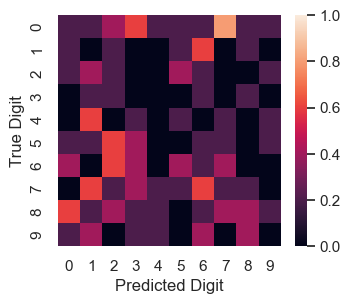

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np

# Assuming you have the true labels and predicted labels
# true_labels = [...]
# predicted_labels = [...]
true_labels = np.random.randint(0, 10, 100)  # Replace with actual true labels
predicted_labels = np.random.randint(0, 10, 100)  # Replace with actual predicted labels

# Generate the confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Plotting
plt.figure(figsize=(3.6, 3))
sns.set(font_scale=1)  # for label size
sns.heatmap(cm/(5), annot=False, annot_kws={"size": 8}, fmt='d', 
            # set cbar to [0, 1]
            vmin=0, vmax=1,
)
# remove cbar
plt.ylabel('True Digit')
plt.xlabel('Predicted Digit')
# plt.title('Confusion Matrix for AudioMNIST')
plt.savefig('confusion_matrix.pdf', dpi=300)
plt.show()

# Reset to default matplotlib settings
plt.rcParams.update(plt.rcParamsDefault)


# Set variables

In [2]:
GROUND_TRUTH_ROOT = "vctk/"
SENSOR_ROOT = "MICEMOUSE/gen/csv"
seed = 42

## Import Needed Libraries

In [3]:
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torchaudio
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.signal import *
import os
import torchinfo
import torchvision.transforms

## Import our own backend

In [4]:
import core.nn.VCTK
from core.signal.preprocess import *
from core.nn.utils import normalize, denormalize, mapToBounds, apply_wiener

## Set seed and logging level

In [5]:
import logging
# fix seed for reproducibility
np.random.seed(seed)
torch.manual_seed(seed)
logging.basicConfig(level=logging.INFO)

In [6]:
Fs = 16000

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
groundTruthConfig = {
    "root": GROUND_TRUTH_ROOT,
    "download": False,
}
sensorConfig = {
    "root": SENSOR_ROOT,
    "Fs": Fs,
    "device": device,
    "resampleMethod": 'sinc'
}

paired_ds = core.nn.VCTK.PairedAudioDataset(groundTruthConfig, sensorConfig)
filtered_paired_ds = core.nn.VCTK.removeOutliers(paired_ds)
train_loader, test_loader, dev_loader = core.nn.VCTK.getAudioLoaders(filtered_paired_ds, device = device, batch_size=32, ret_labels=True)

INFO:root:Initializing PairedAudioDataset...


Removed 1387 outliers 3.16% of the dataset
Remaining 43873 samples
Train: 1129 batches = 36128 samples
Test: 166 batches = 5312 samples
Dev: 34 batches = 1088 samples


In [7]:
speaker_list =  paired_ds.gtDS._speaker_ids
utterance_list = list(set([e[1] for e in paired_ds.gtDS._sample_ids]))
nSpeakers = len(speaker_list)
nUtterances = len(utterance_list)
onehot_speaker = lambda x: torch.eye(nSpeakers)[speaker_list.index(x)]
onehot_utterance = lambda x: torch.eye(nUtterances)[utterance_list.index(x)]
# Is this a clean way to do this? Hell nah
# Is this efficient? Yes

In [8]:
from core.nn.whisperPrimitives import *
device = 'cuda' if torch.cuda.is_available() else 'cpu'
flatten = nn.Flatten()
class permute (nn.Module):
    def forward(self, x):
        return x.permute(0, 2, 1)
utteranceClassifier = nn.Sequential(
    AudioEncoder(n_mels=80, n_ctx=501, n_state=96, n_head = 6, n_layer=2),
    permute(),
    nn.AvgPool1d(501),
    nn.Flatten(),
    nn.Linear(96, 64),
    nn.ReLU(),
    nn.Linear(128, nUtterances),
).to(device)
speakerClassifier = nn.Sequential(
    AudioEncoder(n_mels=80, n_ctx=501, n_state=96, n_head = 6, n_layer=2),
    permute(),
    nn.AvgPool1d(501),
    nn.Flatten(),
    nn.Linear(96, 64),
    nn.ReLU(),
    nn.Linear(64, nSpeakers),
).to(device)

In [9]:
import einops
tforms = core.nn.utils.buildTransforms(device = device, 
                                        Fs = Fs, 
                                        n_fft = 800, 
                                        win_length = 800,
                                        hop_length = 160,
                                        n_mels = 80,
                                        f_max_mouse = 8000,
                                        f_max_full = 8000,
                                        )
specFn, inverseSpecFn, melFilterMouse, melFilter, inverseMelFn = tforms

toMelDB = lambda batch: core.nn.utils.toMelDB(batch, specFn=specFn, mousemelfilters=melFilterMouse, fullmelfilter=melFilter)

def computeUnboundedSpec(X):
    ms = True if X.shape[1] == 2 else False
    if ms:
        X -= einops.reduce(X, "b c t -> b c ()", "mean")  # Remove mean
    else:
        X -= einops.reduce(X, "b t -> b ()", "mean")  # Remove mean
    X /= torch.std(X)                          # Normalize                                        
    X = specFn(X)                                 # Convert to mel
    X = X.abs().pow(2)                           # Power
    
    if ms:
        X = torch.einsum("bkct,fc->bkft", X, melFilterMouse)
        X = einops.rearrange(X, "b c m t -> b (m c) t", c=2)
    else:
        X = torch.einsum("bct,fc->bft", X, melFilter) # Apply mel filter
        
    X = (torch.maximum(torch.clamp(X, min=1e-10).log10(), torch.clamp(X, min=1e-10).log10().max() - 8.0) + 4.0)/ 4.0    # Convert to dB
    return X

# # The following code is used to compute the min and max values of the spectrograms

mnmn = torch.inf
mxmx = -torch.inf
for Mwav, Wwav, _, _ in dev_loader:
    Mfilt = computeUnboundedSpec(Mwav)
    M = computeUnboundedSpec(Mwav)
    W = computeUnboundedSpec(Wwav)
    mnmn = min(mnmn, M.min(), W.min(), Mfilt.min())
    mxmx = max(mxmx, M.max(), W.max(), Mfilt.max())

import einops


def computeSpec(X):
    X = computeUnboundedSpec(X)
    X = (X - mnmn) / (mxmx - mnmn)               # Map to bounds
    X = torch.clamp(X, 0, 1)                    # Clamp to [0, 1]
    X = 2 * X - 1                               # Map to [-1, 1]
    return X

def fromSpec(X):
    if X.shape[1] == 160:
        X = einops.rearrange(X, "b (m c) t -> b c m t", c=2)
        X = torch.mean(X, dim=1)
    X = (X + 1) / 2
    X = X * (mxmx - mnmn) + mnmn
    X = 10 ** (4 * X - 4)
    X = inverseMelFn(X)
    X = inverseSpecFn(X)
    return X

In [10]:
buildClassifier = lambda n_mels, n_classes, time_len: nn.Sequential(
    AudioEncoder(n_mels=n_mels, n_ctx=time_len, n_state=96, n_head = 6, n_layer=4),
    permute(),
    nn.AvgPool1d(time_len),
    nn.Flatten(),
    nn.Linear(96, 64),
    nn.ReLU(),
    nn.Linear(64, n_classes),
).to(device)

def update(model, optimizer, criterion, X, Y, class_list):
    X = X.to(device)
    X = computeSpec(X)

    Y = torch.tensor([class_list.index(i) for i in Y], device=device)
    optimizer.zero_grad()

    output = model(X)
    loss = criterion(output, Y)
    loss.backward()
    optimizer.step()
    return loss.item()

N_EPOCHS = 3

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
net = buildClassifier(80, nSpeakers, 501).to(device)
optimizer = torch.optim.AdamW(net.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()
with tqdm(total = N_EPOCHS * len(train_loader)) as pbar:
    for epoch in range(N_EPOCHS):
        for (X, _, Y, _) in train_loader:
            loss = update(net, optimizer, criterion, X, Y, speaker_list)
            pbar.set_description(f"Loss: {loss:.4f}")
            pbar.update(1)
torch.save(net.state_dict(), "MS_Speaker.pt")

In [14]:
net = buildClassifier(40, nSpeakers, 501).to(device)
optimizer = torch.optim.AdamW(net.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()
with tqdm(total = N_EPOCHS * len(train_loader)) as pbar:
    for epoch in range(N_EPOCHS):
        for (_, X, Y, _) in train_loader:
            loss = update(net, optimizer, criterion, X, Y, speaker_list)
            pbar.set_description(f"Loss: {loss:.4f}")
            pbar.update(1)
torch.save(net.state_dict(), "GT_Speaker.pt")

Loss: 0.2736: 100%|██████████| 3387/3387 [20:51<00:00,  2.71it/s]


In [11]:
net = buildClassifier(80, nSpeakers, 501).to(device)
net.load_state_dict(torch.load("MS_Speaker.pt"))
net.eval()
net2 = buildClassifier(40, nSpeakers, 501).to(device)
net2.load_state_dict(torch.load("GT_Speaker.pt"))
net2.eval()

Sequential(
  (0): AudioEncoder(
    (conv1): Conv1d(80, 96, kernel_size=(15,), stride=(1,), padding=(7,))
    (conv2): Conv1d(96, 96, kernel_size=(15,), stride=(1,), padding=(7,))
    (blocks): ModuleList(
      (0-3): 4 x ResidualAttentionBlock(
        (attn): MultiHeadAttention(
          (query): Linear(in_features=96, out_features=96, bias=True)
          (key): Linear(in_features=96, out_features=96, bias=False)
          (value): Linear(in_features=96, out_features=96, bias=True)
          (out): Linear(in_features=96, out_features=96, bias=True)
        )
        (attn_ln): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
        (mlp): Sequential(
          (0): Linear(in_features=96, out_features=384, bias=True)
          (1): GELU(approximate='none')
          (2): Linear(in_features=384, out_features=96, bias=True)
        )
        (mlp_ln): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
      )
    )
    (ln_post): LayerNorm((96,), eps=1e-05, elementwise_affine

In [12]:
# Get accuracy on test set

def getAccuracy(net, loader, class_list):
    correct = 0
    total = 0
    with torch.no_grad():
        for (X, _, Y, _) in loader:
            X = X.to(device)
            X = computeSpec(X)
            Y = torch.tensor([class_list.index(i) for i in Y], device=device)
            outputs = net(X)
            _, predicted = torch.max(outputs.data, 1)
            total += Y.size(0)
            correct += (predicted == Y).sum().item()
    return correct / total

In [13]:
getAccuracy(net, test_loader, speaker_list)

0.528060263653484

In [14]:
# Get accuracy on test set

def getAccuracy(net, loader, class_list):
    correct = 0
    total = 0
    with torch.no_grad():
        for (_, X, Y, _) in loader:
            X = X.to(device)
            X = computeSpec(X)
            Y = torch.tensor([class_list.index(i) for i in Y], device=device)
            outputs = net(X)
            _, predicted = torch.max(outputs.data, 1)
            total += Y.size(0)
            correct += (predicted == Y).sum().item()
    return correct / total

In [15]:
getAccuracy(net2, test_loader, speaker_list)

0.7990583804143127

In [18]:
net = buildClassifier(80, nUtterances, 501).to(device)
optimizer = torch.optim.AdamW(net.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()
with tqdm(total = N_EPOCHS * len(train_loader)) as pbar:
    for epoch in range(N_EPOCHS):
        for (X, _, _, Y) in train_loader:
            loss = update(net, optimizer, criterion, X, Y, utterance_list)
            pbar.set_description(f"Loss: {loss:.4f}")
            pbar.update(1)
torch.save(net.state_dict(), "MS_Utterance.pt")

Loss: 6.1070: 100%|██████████| 3387/3387 [24:41<00:00,  2.29it/s]


In [20]:
net = buildClassifier(40, nUtterances, 501).to(device)
optimizer = torch.optim.AdamW(net.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()
with tqdm(total = N_EPOCHS * len(train_loader)) as pbar:
    for epoch in range(N_EPOCHS):
        for (_, X, _, Y) in train_loader:
            loss = update(net, optimizer, criterion, X, Y, utterance_list)
            pbar.set_description(f"Loss: {loss:.4f}")
            pbar.update(1)
torch.save(net.state_dict(), "GT_Utterance.pt")

Loss: 5.9831: 100%|██████████| 3387/3387 [21:03<00:00,  2.68it/s]


In [25]:
import core.nn.AudioMNIST

ds = core.nn.AudioMNIST.audioMnistDataset(device = device)
train_loader, test_loader, dev_loader = core.nn.AudioMNIST.getAudioLoaders(ds, device = device, batch_size=32, ret_labels=True)
nDigits = 10
nSpeakersMNIST = 60
digitList = list(range(10)) # Very hacky
speakerListMNIST = list(range(61))
N_EPOCHS = 5

Train: 797 batches = 25504 samples
Test: 118 batches = 3776 samples
Dev: 24 batches = 768 samples


In [26]:
# out_mouse, out_wavs, out_digit, out_speaker
net = buildClassifier(40, nSpeakersMNIST, 101).to(device)
optimizer = torch.optim.AdamW(net.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()
with tqdm(total = N_EPOCHS * len(train_loader)) as pbar:
    for epoch in range(N_EPOCHS):
        for (_, X, _, Y) in train_loader:
            loss = update(net, optimizer, criterion, X, Y, speakerListMNIST)
            pbar.set_description(f"Loss: {loss:.4f}")
            pbar.update(1)
torch.save(net.state_dict(), "MNIST_GT_speaker.pt")

Loss: 4.0823:   0%|          | 3/3985 [00:02<47:50,  1.39it/s]


RuntimeError: CUDA error: device-side assert triggered
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1.
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [ ]:
# out_mouse, out_wavs, out_digit, out_speaker
net = buildClassifier(40, nSpeakersMNIST, 101).to(device)
optimizer = torch.optim.AdamW(net.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()
with tqdm(total = N_EPOCHS * len(train_loader)) as pbar:
    for epoch in range(N_EPOCHS):
        for (_, X, Y, _) in train_loader:
            loss = update(net, optimizer, criterion, X, Y, digitList)
            pbar.set_description(f"Loss: {loss:.4f}")
            pbar.update(1)
torch.save(net.state_dict(), "MNIST_GT_digit.pt")

In [56]:
speakerListMNIST.index(next(iter(train_loader))[-2][0]) 

1